# All simulations used in our thesis

Spørgsmål og undren her: (skal slettes når der fås styr på dette)

Afkast: 
- Indtil videre i vores simulationer har vi brugt månedligt afkast $R_{m} = 0.10$, hvilket svarer til årligt afkast $R_{y} = (1 + 0.10)^{12} - 1 \approx 2.138 = 213.8\%$ om året. Dette er meget urealistisk. Skal dette passe med hvad der er normalt e.g. 7\% om året ville det månedlige afkast være $R_m = (1+0.07)^{1/12} - 1 \approx 0,005654 = 0.56\%$ om måneden. 
- Problemet er, at hvis vi bruger denne rente, så vil vi ikke kunne frembringe nogen bobler i vores simulationer. Afkastet bliver alt for lavt til at boblen kan gro hurtigt nok. Det vil kræve en enorm lang tidshorisont.

### In this notebook all simulations are displayed

In [2]:
%load_ext rpy2.ipython
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
import importlib
sys.path.append(os.path.abspath(".."))

# Import functions
from functions import simulation_master_v2
from functions import simulation_master_v3
from functions import bertelsen_5_2
from functions import bertelsen_5_3

# Reload functions
importlib.reload(simulation_master_v2)
importlib.reload(simulation_master_v3)
importlib.reload(bertelsen_5_2)
importlib.reload(bertelsen_5_3)


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <BBF229FE-E7FC-30D6-AD24-713D50386A7C> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


<module 'functions.bertelsen_5_3' from '/Users/emilrand/Desktop/ku/Bachelor/6. semester/ba/ba_repo/functions/bertelsen_5_3.py'>

### Equations used for simulations

The equations for our simulations stem from the theoretical section in our thesis, and are given by: 

<!-- \begin{align*}
D_{t+1} &= \mu + \rho D_t + \varepsilon_{D_{t+1}}, \quad \varepsilon_{D_t} \overset{i.i.d}{\sim} N(\mu_D, \sigma_D^2) \tag{Dividend process} \\
    P_t^f &= \frac{\rho}{1+R-\rho}D_t + \frac{(\mu+\mu_D)(1+R)}{R(1+R-\rho)} \tag{Price fundamentals} \\
    B_{t+1} &= (1+R)B_t + \varepsilon_{B_{t+1}}, \quad \varepsilon_{B_t} \overset{i.i.d}{\sim} N(\mu_B, \sigma_B^2) \tag{Bubble component} \\
    P_t &= P_t^f + B_t \tag{Stock price}
\end{align*} -->



### Bertelsen sec. 5.2 method

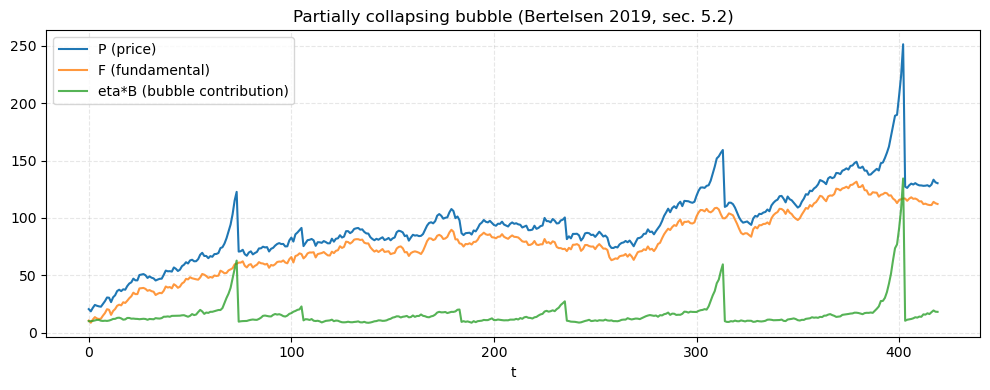

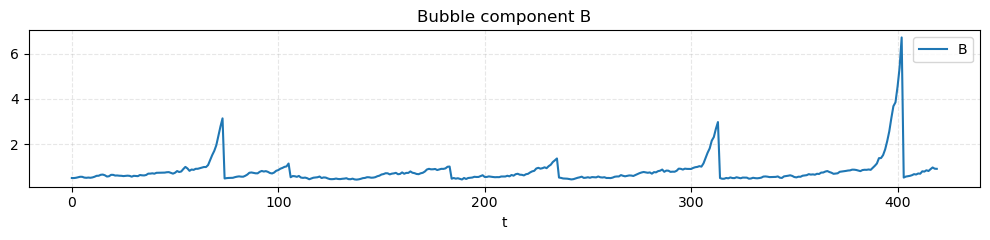

In [14]:
# Partially collapsing bubble (Bertelsen 2019, section 5.2)
# Important: the bubble is multiplicative, so if B0 = 0 then B stays 0.

T = 420
seed = 123

# Paper defaults (you can tweak these)
mu = 0.0024
rho = 0.985
alpha = 1.0
pi = 0.85 # 0.85 is default. probability of bubble collapse.
delta = 0.5
sigma_D = 0.0316
sigma_B = 0.05
eta = 20.0

D, F, B, P = bertelsen_5_2.simulate_partially_collapsing_bubble(
    T=T,
    mu=mu,
    rho=rho,
    alpha=alpha,
    pi=pi,
    delta=delta,
    sigma_D=sigma_D,
    sigma_B=sigma_B,
    eta=eta,
    B0=delta,   # start bubble at delta (otherwise it stays flat at 0)
    seed=seed,
)

plt.figure(figsize=(10, 4))
plt.plot(P, label="P (price)")
plt.plot(F, label="F (fundamental)", alpha=0.8)
plt.plot(eta * B, label="eta*B (bubble contribution)", alpha=0.8)
plt.title("Partially collapsing bubble (Bertelsen 2019, sec. 5.2)")
plt.xlabel("t")
plt.legend()
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 2.5))
plt.plot(B, label="B")
plt.title("Bubble component B")
plt.xlabel("t")
plt.legend()
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

### Bertelsen 5.3: Random walk with explosive period(s)

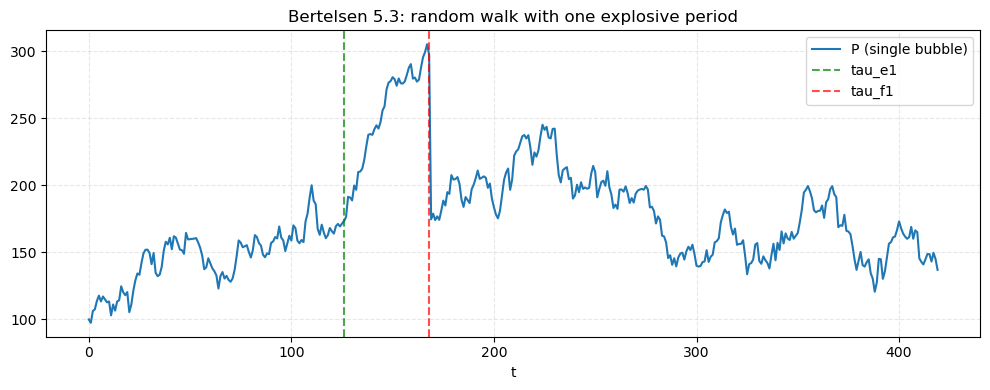

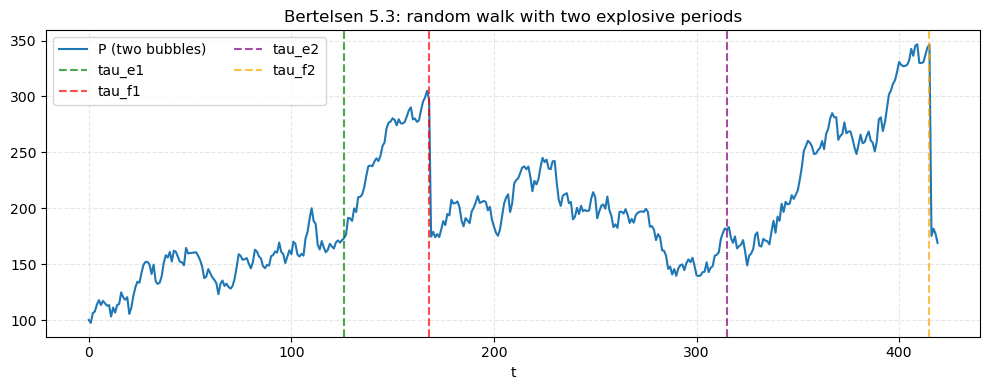

In [36]:
from functions.bertelsen_5_3 import simulate_rw_explosive_periods, ExplosivePeriod

# Single explosive period (Bertelsen 2019, section 5.3 defaults)
T = 420
window1 = ExplosivePeriod(0.3, 0.4)

tau_e1 = int(np.floor(window1.r_e * T))
tau_f1 = int(np.floor(window1.r_f * T))

P_single = simulate_rw_explosive_periods(
    T=T,
    P0=100,
    sigma=6.79,
    c=1.0,
    alpha=0.8,
    window1=window1,
    seed=123,
)

plt.figure(figsize=(10, 4))
plt.plot(P_single, label="P (single bubble)")
plt.axvline(tau_e1, color="green", linestyle="--", alpha=0.7, label="tau_e1")
plt.axvline(tau_f1, color="red", linestyle="--", alpha=0.7, label="tau_f1")
plt.title("Bertelsen 5.3: random walk with one explosive period")
plt.xlabel("t")
plt.legend()
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# Optional: two explosive periods
window2 = ExplosivePeriod(0.75, 0.99)
tau_e2 = int(np.floor(window2.r_e * T))
tau_f2 = int(np.floor(window2.r_f * T))

P_two = simulate_rw_explosive_periods(
    T=T,
    P0=100,
    sigma=6.79,
    c=1.0,
    alpha=0.8,
    window1=window1,
    window2=window2,
    seed=123,
)

plt.figure(figsize=(10, 4))
plt.plot(P_two, label="P (two bubbles)")
for x, label, color in [
    (tau_e1, "tau_e1", "green"),
    (tau_f1, "tau_f1", "red"),
    (tau_e2, "tau_e2", "purple"),
    (tau_f2, "tau_f2", "orange"),
]:
    plt.axvline(x, color=color, linestyle="--", alpha=0.7, label=label)
plt.title("Bertelsen 5.3: random walk with two explosive periods")
plt.xlabel("t")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

In [37]:
# Save P_two
P_two.to_csv('../emil/P_two.csv', index = True, index_label = 't', header = ['P_two'])

In [38]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('P_two.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_two)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "P_two_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "P_two_cv.csv", row.names = FALSE)




── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id        adf       sadf     gsadf
  series1  -2.632187  0.8668501  1.779604

  gsadf_panel
     1.779604


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.42229340  1.146362  1.934428
   95  -0.05957989  1.448922  2.162211
   99   0.55426333  2.039598  2.622547



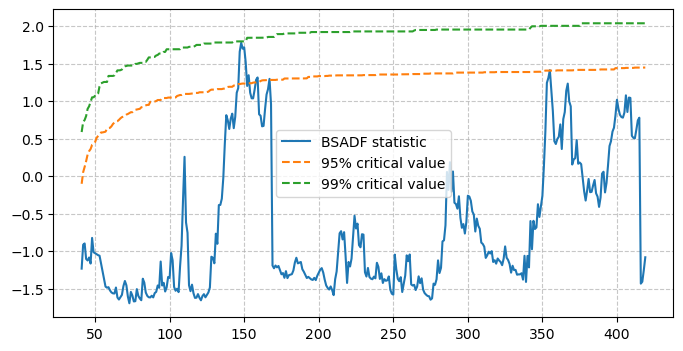

In [39]:
# plot bsadf and critical values from the csv files

bsadf_stat = pd.read_csv("P_two_bsadf.csv")
bsadf_cv   = pd.read_csv("P_two_cv.csv")

t = P_two.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.show()

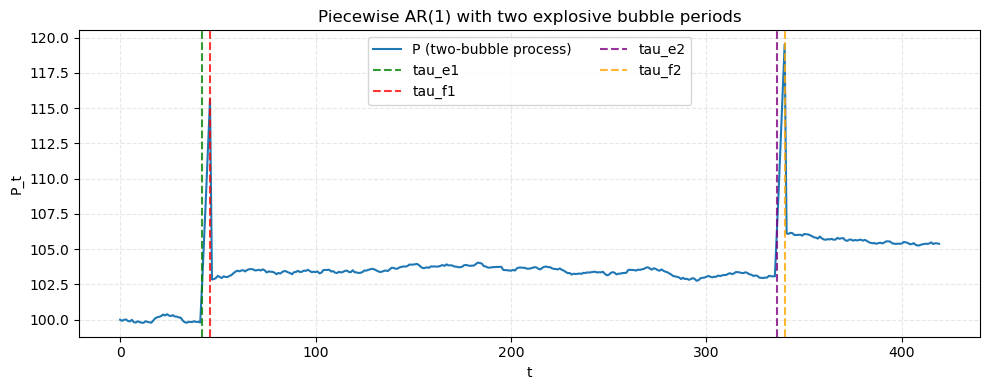

In [7]:
# Two-bubble simulation using the v3 process
P_two, meta = simulation_master_v3.simulate_piecewise_bubble_process_two(
    T=420,
    d=1.0,
    eta=1.0,
    rho=1.03,
    sigma=0.07,
    P0=100.0,
    r_e1=0.10,
    r_f1=0.11,
    r_e2=0.80,
    r_f2=0.81,
    seed=123,
    return_meta=True,
)

plt.figure(figsize=(10, 4))
plt.plot(P_two, label="P (two-bubble process)")

for x, label, color in [
    (meta["tau_e1"], "tau_e1", "green"),
    (meta["tau_f1"], "tau_f1", "red"),
    (meta["tau_e2"], "tau_e2", "purple"),
    (meta["tau_f2"], "tau_f2", "orange"),
]:
    plt.axvline(x, color=color, linestyle="--", alpha=0.8, label=label)

plt.title("Piecewise AR(1) with two explosive bubble periods")
plt.xlabel("t")
plt.ylabel("P_t")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# optional save
# P_two.to_csv("P_two.csv", index=False, header=["P_two"])

### Simple AR(1) with weak drift